###### Create a Batsman Summery using given data, also help him to know what went wrong, scope of improvment.

In [34]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel
from langchain.messages import SystemMessage, HumanMessage

In [35]:
load_dotenv()
llm_model = ChatOpenAI(model="gpt-4-0613")

In [36]:
class BatsmanSchema(TypedDict):
    runs: int
    four: int
    six: int
    balls: int
    strike_rate: float
    boundry_per_ball: float
    boundry_per_score: float
    summery: str
    suggestions: str

In [ ]:
def calculate_SR(state: BatsmanSchema):
    '''This function will calculate the Strike Rate of the Batsman'''
    strike_rate = (state['runs']/state['balls']) * 100
    return {'strike_rate':strike_rate}


def calculate_BPB(state:BatsmanSchema):
    boundry_count = state['four'] + state['six']
    balls_played = state['balls']
    boundry_per_ball = balls_played/boundry_count
    return {'boundry_per_ball':boundry_per_ball}


def calculate_BPS(state:BatsmanSchema):
    boundry_score = (state['four']*4)+(state['six']*6)
    total_runs = state['runs']
    boundry_per_score = (boundry_score/total_runs) * 100
    return {'boundry_per_score':boundry_per_score}

def batsman_summery(state:BatsmanSchema):
    summery = f'''
        Based on the Cricket Summery given below suggest what went right and area of Improvement to the Batsman\n
Cricket Summery\n
Runs_scored = {state['runs']}\n
Fours = {state['four']}\n
sixes = {state['six']}\n
balls played = {state['balls']}
strike_rate = {state['strike_rate']}
boundry_per_ball= {state['boundry_per_ball']}
boundry_per_score = {state['boundry_per_score']}   
'''
    return {'summery':summery}

def suggest_improvements(state:BatsmanSchema):
    prompt = [
        SystemMessage(content='You are a Cricket Expert Analyst.'),
        HumanMessage(content=state['summery'])
    ]

    response = llm_model.invoke(prompt)
    return {'suggestions': response.content}

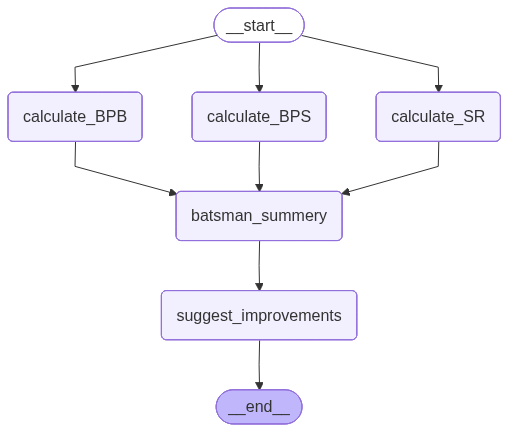

In [38]:
graph = StateGraph(BatsmanSchema)

## add node
graph.add_node('calculate_SR', calculate_SR)
graph.add_node('calculate_BPB', calculate_BPB)
graph.add_node('calculate_BPS', calculate_BPS)
graph.add_node('batsman_summery', batsman_summery)
graph.add_node('suggest_improvements', suggest_improvements)

## add edges
graph.add_edge(START, 'calculate_SR')
graph.add_edge(START, 'calculate_BPB')
graph.add_edge(START, 'calculate_BPS')

graph.add_edge('calculate_SR', 'batsman_summery')
graph.add_edge('calculate_BPB', 'batsman_summery')
graph.add_edge('calculate_BPS', 'batsman_summery')
graph.add_edge('batsman_summery', 'suggest_improvements')

graph.add_edge('suggest_improvements', END)


final_graph = graph.compile()
final_graph

In [41]:
initial_state = {
    "runs": 75,
    "four": 0,
    "six": 1,
    "balls": 150,
    "strike_rate": "",
    "boundry_per_ball": "",
    "boundry_per_score": "float",
    "summery": "",
    "suggestions": ""
}
response = final_graph.invoke(initial_state)
response

{'runs': 75,
 'four': 0,
 'six': 1,
 'balls': 150,
 'strike_rate': 50.0,
 'boundry_per_ball': 150.0,
 'boundry_per_score': 8.0,
 'summery': '\n        Based on the Cricket Summery given below suggest what went right and area of Improvement to the Batsman\n\nCricket Summery\n\nRuns_scored = 75\n\nFours = 0\n\nsixes = 1\n\nballs played = 150\nstrike_rate = 50.0\nboundry_per_ball= 150.0\nboundry_per_score = 8.0   \n',
 'suggestions': "What went right:\n\n1. The batsman managed to score a respectable total of 75 runs which is a substantial contribution to the team's overall score.\n2. The batsman clearly managed to stay on the pitch for a considerable amount of time, showing good defensive strategies and overall endurance. Having faced 150 balls implies his ability to build an innings and potentially increase the team's score.\n\nAreas of Improvement:\n\n1. Boundary Scoring: The batsman scored only one six and zero fours. This is a relatively low boundary count given the number of balls fa